<a href="https://0ghosto.github.io/MIRNoteByAndrew/" style="display:inline-flex;align-items:center;gap:6px;text-decoration:none;font-family:'Inter',sans-serif;font-size:0.82rem;font-weight:500;color:#c96442;background:#fef6f2;border:1px solid #f0d4c8;border-radius:8px;padding:6px 12px;margin-bottom:8px;">&#8592; Home</a>

# Chapter 4: MIDI Note to frequency


- **note:** name of the note
- **midi-ET:** MIDI number, *equal temperament*
- **Hertz-ET:** frequency in Hertz, *equal temperament*
- **midi-PT:** MIDI number, *Pythagorean tuning*
- **Hertz-PT:** frequency in Hertz, *Pythagorean tuning*

In [4]:
import numpy as np
import pandas as pd

# ── Constants ─────────────────────────────────────────────────────────────────
A4_MIDI = 69
A4_FREQ = 440.0
C4_PT   = A4_FREQ * 16 / 27   # C4 in Pythagorean tuning  (A = C × 27/16)

# ── Pythagorean structure ──────────────────────────────────────────────────────
# Number of perfect fifths (3/2) above C to reach each pitch class
FIFTHS_FROM_C = {
    'Cb': -7, 'C':  0, 'C#':  7, 'Db': -5,
    'D':   2, 'D#':  9, 'Eb': -3, 'E':   4,
    'E#': 11, 'Fb': -8, 'F':  -1, 'F#':  6,
    'Gb': -6, 'G':   1, 'G#':  8, 'Ab': -4,
    'A':   3, 'A#': 10, 'Bb': -2, 'B':   5,
    'B#': 12,
}

# Semitones from C (for ET MIDI; Cb = -1, B# = 12)
SEMITONES_FROM_C = {
    'Cb': -1, 'C':  0, 'C#':  1, 'Db':  1,
    'D':   2, 'D#':  3, 'Eb':  3, 'E':   4,
    'E#':  5, 'Fb':  4, 'F':   5, 'F#':  6,
    'Gb':  6, 'G':   7, 'G#':  8, 'Ab':  8,
    'A':   9, 'A#': 10, 'Bb': 10, 'B':  11,
    'B#': 12,
}

def _pt_ratio(n_fifths):
    """Pythagorean ratio relative to C, normalised to [1, 2)."""
    r = (3 / 2) ** n_fifths
    while r >= 2.0: r /= 2.0
    while r  < 1.0: r *= 2.0
    return r

def _note_row(name, octave):
    midi_et  = 12 * (octave + 1) + SEMITONES_FROM_C[name]
    freq_et  = A4_FREQ * 2 ** ((midi_et - A4_MIDI) / 12)
    pt_base  = C4_PT * _pt_ratio(FIFTHS_FROM_C[name])
    k        = round(np.log2(freq_et / pt_base))       # octave shift
    freq_pt  = pt_base * 2 ** k
    midi_pt  = A4_MIDI + 12 * np.log2(freq_pt / A4_FREQ)
    return {
        'note'    : f'{name}{octave}',
        'midi-ET' : midi_et,
        'Hertz-ET': round(freq_et, 3),
        'midi-PT' : round(midi_pt, 3),
        'Hertz-PT': round(freq_pt, 3),
    }

# ── Build note list in the same order as the reference tables ─────────────────
rows = []

# Block 0: Cb0 … G#0
for n in ['Cb','C','Db','C#','D','Eb','D#','Fb','E','F','E#','Gb','F#','G','Ab','G#']:
    rows.append(_note_row(n, 0))

# Blocks 1–9: A_k … G#_(k+1)
HIGH = {'A', 'Bb', 'A#', 'B', 'B#'}   # stay in lower octave k
SEQ  = ['A','Bb','A#','Cb','B','C','B#','Db','C#','D',
        'Eb','D#','Fb','E','F','E#','Gb','F#','G','Ab','G#']
for base in range(9):
    for n in SEQ:
        rows.append(_note_row(n, base if n in HIGH else base + 1))

# Final block: A9 … B#9
for n in ['A', 'Bb', 'A#', 'B', 'B#']:
    rows.append(_note_row(n, 9))

df = pd.DataFrame(rows)

with pd.option_context('display.max_rows', None):
    display(df)

,note,midi-ET,Hertz-ET,midi-PT,Hertz-PT
0,Cb0,11,15.434,10.804,15.261
1,C0,12,16.352,11.941,16.296
2,Db0,13,17.324,12.844,17.168
3,C#0,13,17.324,13.078,17.402
4,D0,14,18.354,13.980,18.333
5,Eb0,15,19.445,14.883,19.314
6,D#0,15,19.445,15.117,19.578
7,Fb0,16,20.602,15.785,20.347
8,E0,16,20.602,16.020,20.625
9,F0,17,21.827,16.922,21.728


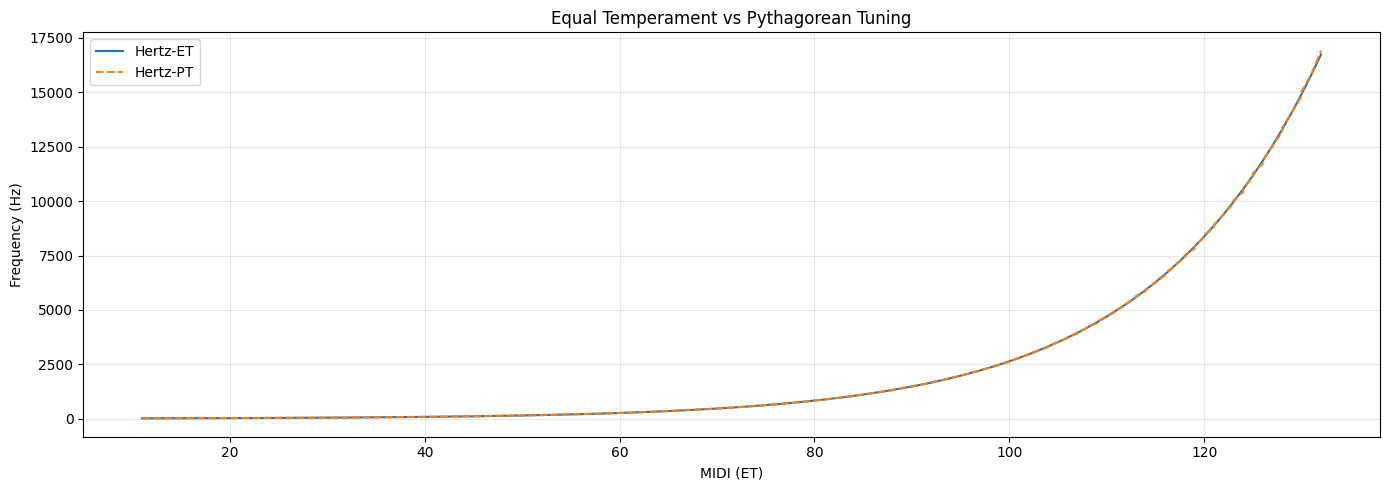

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df['midi-ET'], df['Hertz-ET'], label='Hertz-ET', linewidth=1.5)
plt.plot(df['midi-ET'], df['Hertz-PT'], label='Hertz-PT', linewidth=1.5, linestyle='--')
plt.xlabel('MIDI (ET)')
plt.ylabel('Frequency (Hz)')
plt.title('Equal Temperament vs Pythagorean Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Why the Hz difference looks small but sounds noticeable

The Hz graph looks almost identical because the *absolute* difference is tiny against an exponential frequency range.  
But the ear doesn't judge frequency linearly — it judges **ratios**, measured in **cents** (1 semitone = 100 cents).

$$\text{cents deviation} = 100 \times (\text{midi-PT} - \text{midi-ET})$$

- ET slightly flattens every perfect fifth by ~2 cents to close the circle evenly.  
- PT keeps the fifth pure (3:2) but lets the thirds drift wide (~+8 cents vs ET, ~+22 cents vs just intonation).  
- The **Pythagorean comma** (~23.5 cents) is the total drift after stacking 12 pure fifths — ET spreads this evenly; PT hides it in one "wolf" interval.  
- Humans can detect ~5 cents in isolation, and beating between harmonics makes even 2–3 cents audible in chords.

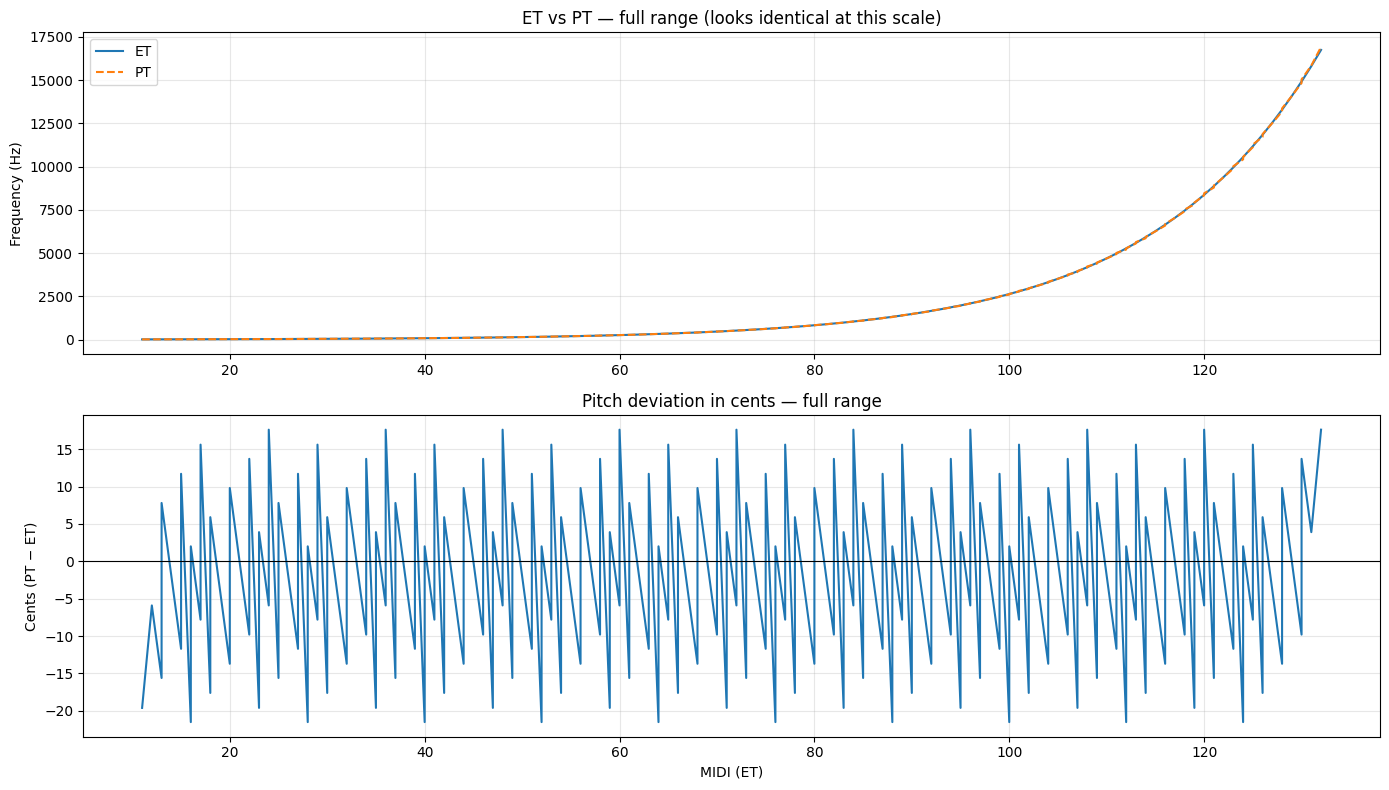

In [10]:
df['cents_diff'] = 100 * (df['midi-PT'] - df['midi-ET'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Top: full range Hz plot ───────────────────────────────────────────────────
axes[0].plot(df['midi-ET'], df['Hertz-ET'], label='ET',  linewidth=1.5)
axes[0].plot(df['midi-ET'], df['Hertz-PT'], label='PT',  linewidth=1.5, linestyle='--')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('ET vs PT — full range (looks identical at this scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Bottom: cents deviation ───────────────────────────────────────────────────
axes[1].plot(df['midi-ET'], df['cents_diff'], linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('MIDI (ET)')
axes[1].set_ylabel('Cents (PT − ET)')
axes[1].set_title('Pitch deviation in cents — full range')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
> April 9th: I studied and roam around wondering if the "old" Pythagorean tuning's difference between equal-temperament. It shows the patterned difference. 